### Load movie features and prepare clustering inputs

In [66]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import TruncatedSVD

ROOT = Path.cwd().parent
movies_feature_file = ROOT / "data" / "features" / "movies_features.csv"
df = pd.read_csv(movies_feature_file)

print("DataFrame shape:", df.shape)

DataFrame shape: (2963, 30)


In [67]:
# vote_count est volontairement absent : il a servi à créer la cible.
num_features = [
    "runtime",
    "budget",
    "revenue",
    "vote_average",
    "release_year",
    "release_month",
    "genre_count",
    "keyword_count",
    "roi",
    "movie_age"
]

categorical_features = [
    "original_language",
    "status",
    "runtime_category"
]

lists_columns = [
    "genres",
    "keywords"
]
import ast

def parse_names(value):
    if pd.isna(value):
        return []
    try:
        items = ast.literal_eval(value) if isinstance(value, str) else value
        return [item["name"] for item in items if isinstance(item, dict) and "name" in item]
    except (ValueError, SyntaxError, TypeError):
        return []

df["genres"] = df["genres"].apply(lambda value: ",".join(parse_names(value)) or "no_genre")
df["keywords"] = df["keywords"].apply(lambda value: " ".join(parse_names(value)))

# Text vectorizers cannot process NaN values. Treat missing text as empty text.
df["keywords"] = df["keywords"].fillna("")
df["overview"] = df["overview"].fillna("")

features = num_features + categorical_features + lists_columns

In [68]:
from sklearn.compose import ColumnTransformer
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

numeric_preprocessor = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_preprocessor = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer([
    ("numeric", numeric_preprocessor, num_features),
    ("categorical", categorical_preprocessor, categorical_features),
    ("genres", CountVectorizer(binary=True, token_pattern=r"[^,]+"), "genres"),
    ("keywords", TfidfVectorizer(max_features=5000, ngram_range=(1, 2), stop_words="english"), "keywords"),
    ("overview", TfidfVectorizer(max_features=5000, ngram_range=(1, 2), stop_words="english"), "overview")
])

In [69]:
cluster_features = features + ["overview"]
X_cluster = preprocessor.fit_transform(df[cluster_features])
print("Combined feature matrix:", X_cluster.shape)

Combined feature matrix: (2963, 10072)


### Test several K values

In [70]:
k_values = range(2, 11)

silhouette_scores = []

for k in k_values:

    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = kmeans.fit_predict(X_cluster)
    score = silhouette_score(X_cluster,labels)

    silhouette_scores.append(score)
    print(f"K={k} → Silhouette Score={score:.4f}")

K=2 → Silhouette Score=0.1201
K=3 → Silhouette Score=0.1329
K=4 → Silhouette Score=0.1317
K=5 → Silhouette Score=0.0983
K=6 → Silhouette Score=0.1011
K=7 → Silhouette Score=0.1087
K=8 → Silhouette Score=0.0865
K=9 → Silhouette Score=0.0838
K=10 → Silhouette Score=0.0833


### Visualize the scores

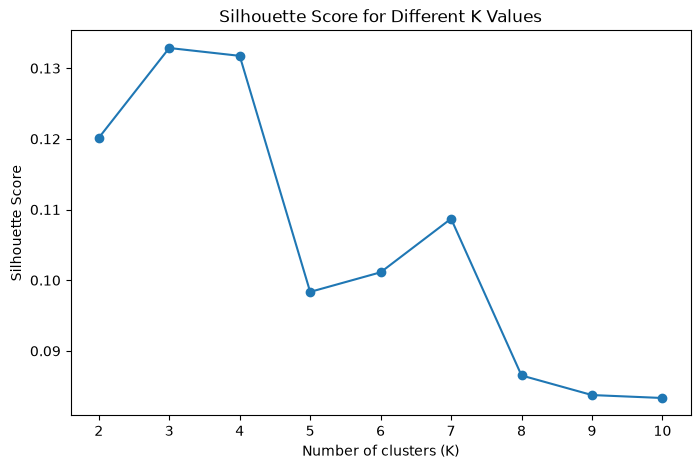

In [71]:
plt.figure(figsize=(8, 5))

plt.plot(
    k_values,
    silhouette_scores,
    marker="o"
)

plt.xlabel("Number of clusters (K)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score for Different K Values")
plt.xticks(list(k_values))

plt.show()

### Select the best K

In [72]:
best_k = list(k_values)[
    np.argmax(silhouette_scores)
]

best_score = max(silhouette_scores)

print("Best K:", best_k)
print("Best Silhouette Score:", round(best_score, 4))

Best K: 3
Best Silhouette Score: 0.1329


### Train the final K-Means

In [73]:
kmeans_final = KMeans(
    n_clusters=best_k,
    random_state=42,
    n_init=10
)

cluster_labels = kmeans_final.fit_predict(X_cluster)

df["cluster"] = cluster_labels

In [74]:
print(df["cluster"].value_counts().sort_index())

cluster
0     531
1    1682
2     750
Name: count, dtype: int64


### Interpret the clusters using their strongest features

In [75]:
feature_names = preprocessor.get_feature_names_out()

In [76]:
for cluster in sorted(df["cluster"].unique()):
    cluster_indices = np.where(df["cluster"].values == cluster)[0]
    cluster_features_matrix = X_cluster[cluster_indices]

    mean_values = np.asarray(cluster_features_matrix.mean(axis=0)).ravel()
    top_indices = mean_values.argsort()[-10:][::-1]
    top_features = feature_names[top_indices]
    cluster_profile = df.groupby("cluster")[num_features].mean()
    cluster_profile.round(2)

    print(f"\nCluster {cluster}")
    print("Top features:")
    print(", ".join(top_features))


Cluster 0
Top features:
numeric__budget, numeric__revenue, categorical__status_Released, categorical__original_language_en, genres__adventure, numeric__genre_count, genres__action, numeric__runtime, categorical__runtime_category_Medium, categorical__runtime_category_Long

Cluster 1
Top features:
categorical__status_Released, categorical__original_language_en, categorical__runtime_category_Medium, numeric__release_year, genres__drama, genres__comedy, genres__thriller, genres__action, genres__horror, categorical__runtime_category_Long

Cluster 2
Top features:
numeric__movie_age, categorical__status_Released, categorical__original_language_en, categorical__runtime_category_Medium, numeric__keyword_count, genres__drama, numeric__vote_average, categorical__runtime_category_Long, genres__thriller, genres__comedy


### See example movies from each cluster

In [77]:
for cluster in sorted(df["cluster"].unique()):

    print(f"\n{'=' * 40}")
    print(f"CLUSTER {cluster}")
    print(f"{'=' * 40}")

    movies = df[
        df["cluster"] == cluster
    ][["title", "genres", "keywords"]].head(10)

    print(movies.to_string(index=False))


CLUSTER 0
                    title                                    genres                                                                                                                                                                                                                                                              keywords
Spider-Man: Brand New Day          Science Fiction,Action,Adventure mind control new york city hero mutation secret identity superhero spider villain based on comic sequel transhumanism super power masked vigilante spider web aftercreditsstinger marvel cinematic universe (mcu) masked superhero fight for justice genetic mutation
              The Odyssey                  Adventure,Action,Fantasy                               ship trojan war greek mythology historical fiction ancient world period drama based on song, poem or rhyme greek history voyage peplum ancient trojan horse mediterranean sea bronze age mythical odyssey sword and sandal epic fantasy

### TruncatedSVD for 2D visualization

In [78]:
svd = TruncatedSVD(
    n_components=2,
    random_state=42
)

X_2d = svd.fit_transform(X_cluster)

print("2D shape:", X_2d.shape)

2D shape: (2963, 2)


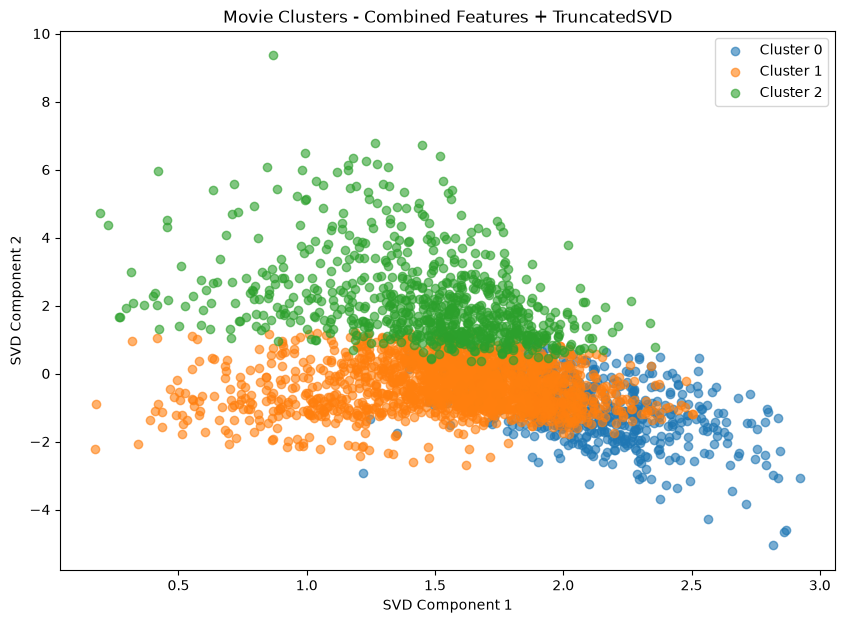

In [79]:
plt.figure(figsize=(10, 7))

for cluster in sorted(df["cluster"].unique()):

    mask = df["cluster"] == cluster

    plt.scatter(
        X_2d[mask, 0],
        X_2d[mask, 1],
        label=f"Cluster {cluster}",
        alpha=0.6
    )

plt.xlabel("SVD Component 1")
plt.ylabel("SVD Component 2")
plt.title("Movie Clusters - Combined Features + TruncatedSVD")
plt.legend()
plt.show()